In [2]:
!pip install geopandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.9 MB ? eta -:--:--
   - -------------------------------------- 1.0/22.9 MB 2.5 MB/s eta 0:00:09
   -- ------------------------------------- 1.6/22.9 MB 3.0 MB/s eta 0:00:08
   -- ------------------------------------- 1.6/22.9 MB 3.0 MB/s eta 0:00:08
   --- ------------------------------------ 1.8/22.9 MB 1.8 MB/s eta 0:00:12
   --- ------------------------------------ 2.1/22.9 MB 1.8 MB/s eta 0:00:12
   ---- ----------------------------------- 2.4/22.9 MB 1.7 MB/s eta 0:00:13
   ---- ----------------------------------- 2.6/22.9 MB 1.6 MB/s eta 0:00:13
   ----- ---------------------------------- 2.9/22.9 MB 1.6 MB/s eta 0:00:13
   ----- ---------------------------------- 3.1/22.9 MB 1.4 MB/s eta 0:00:14
   ----- ---------------------------------- 3.4/22.9 MB 1.5 MB/s eta 0:00:13
   ------ --

In [3]:
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
%matplotlib inline

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/acs2015_county_data.csv', encoding='utf-8').dropna()
df.head()

,CensusId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001,Alabama,Autauga,55221,26745,28476,2.6,75.8,18.5,0.4,...,0.5,1.3,1.8,26.5,23986,73.6,20.9,5.5,0.0,7.6
1,1003,Alabama,Baldwin,195121,95314,99807,4.5,83.1,9.5,0.6,...,1.0,1.4,3.9,26.4,85953,81.5,12.3,5.8,0.4,7.5
2,1005,Alabama,Barbour,26932,14497,12435,4.6,46.2,46.7,0.2,...,1.8,1.5,1.6,24.1,8597,71.8,20.8,7.3,0.1,17.6
3,1007,Alabama,Bibb,22604,12073,10531,2.2,74.5,21.4,0.4,...,0.6,1.5,0.7,28.8,8294,76.8,16.1,6.7,0.4,8.3
4,1009,Alabama,Blount,57710,28512,29198,8.6,87.9,1.5,0.3,...,0.9,0.4,2.3,34.9,22189,82.0,13.5,4.2,0.4,7.7


In [5]:
labels = ['CensusId', 'State', 'County']
features = [col for col in df.columns if col not in labels]

scaler = StandardScaler()
df[features] = df[features].astype('float64')
X = scaler.fit_transform(df[features])

In [6]:
hc = AgglomerativeClustering(n_clusters=4, linkage='ward', metric='euclidean').fit(X)
df['cluster'] = hc.labels_ + 1
df['cluster'] = df['cluster'].astype('int64')

In [7]:
sns.palplot(sns.color_palette("Set1", n_colors=4))
sns.palplot(sns.color_palette("Set2", n_colors=4))
sns.palplot(sns.color_palette("Set3", n_colors=4))
sns.palplot(sns.color_palette("Paired", n_colors=4))

In [8]:
colours = ["windows blue", "amber", "coral", "faded green"]
# plot them as a palette
sns.palplot(sns.xkcd_palette(colours))

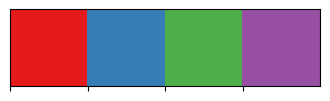

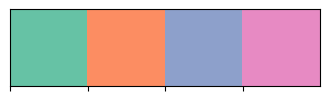

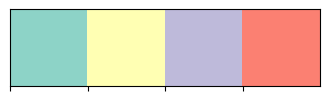

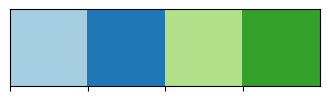

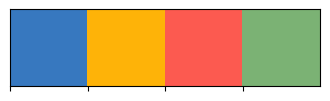

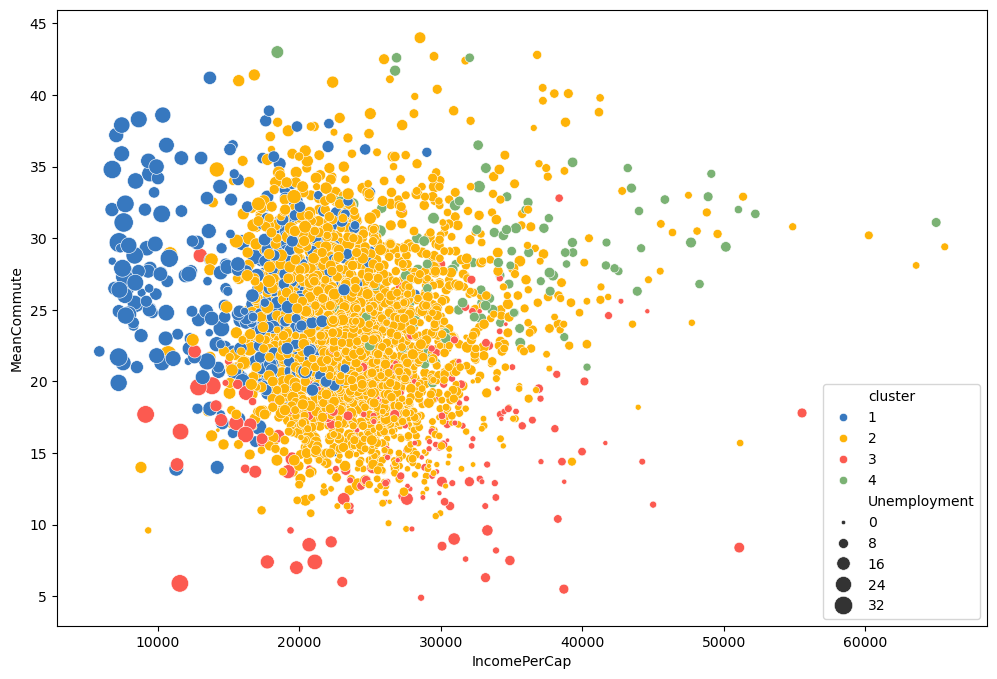

In [9]:
# create our colour palette
cmap = sns.xkcd_palette(colours)
plt.figure(figsize=(12,8))
ax = sns.scatterplot(x="IncomePerCap", y="MeanCommute",
                     hue="cluster", size="Unemployment",
                     palette=cmap, sizes=(10, 200),
                     data=df)
plt.show()

In [10]:
gdf = gpd.read_file('https://raw.githubusercontent.com/python-visualization/folium/master/tests/us-counties.json')

In [11]:
gdf.head()

,id,name,geometry
0,1001,Autauga,"POLYGON ((-86.41179 32.70634, -86.41179 32.410..."
1,1003,Baldwin,"POLYGON ((-87.76459 31.29877, -87.61671 31.244..."
2,1005,Barbour,"POLYGON ((-85.35474 32.14769, -85.0535 32.0655..."
3,1007,Bibb,"POLYGON ((-87.06354 33.24856, -87.0252 33.2485..."
4,1009,Blount,"POLYGON ((-86.48846 34.26179, -86.4556 34.2617..."


In [12]:
gdf['id'] = gdf['id'].astype('int64')
df = pd.merge(left=df, right=gdf, how='inner', left_on='CensusId', right_on='id')
del df['id']
del df['name']
# convert to a GeoDataFrame, specifying which column we wish to use for the geometry info
df = gpd.GeoDataFrame(df, geometry='geometry')
df.head(3)

,CensusId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment,cluster,geometry
0,1001,Alabama,Autauga,55221.0,26745.0,28476.0,2.6,75.8,18.5,0.4,...,1.8,26.5,23986.0,73.6,20.9,5.5,0.0,7.6,2,"POLYGON ((-86.41179 32.70634, -86.41179 32.410..."
1,1003,Alabama,Baldwin,195121.0,95314.0,99807.0,4.5,83.1,9.5,0.6,...,3.9,26.4,85953.0,81.5,12.3,5.8,0.4,7.5,2,"POLYGON ((-87.76459 31.29877, -87.61671 31.244..."
2,1005,Alabama,Barbour,26932.0,14497.0,12435.0,4.6,46.2,46.7,0.2,...,1.6,24.1,8597.0,71.8,20.8,7.3,0.1,17.6,1,"POLYGON ((-85.35474 32.14769, -85.0535 32.0655..."


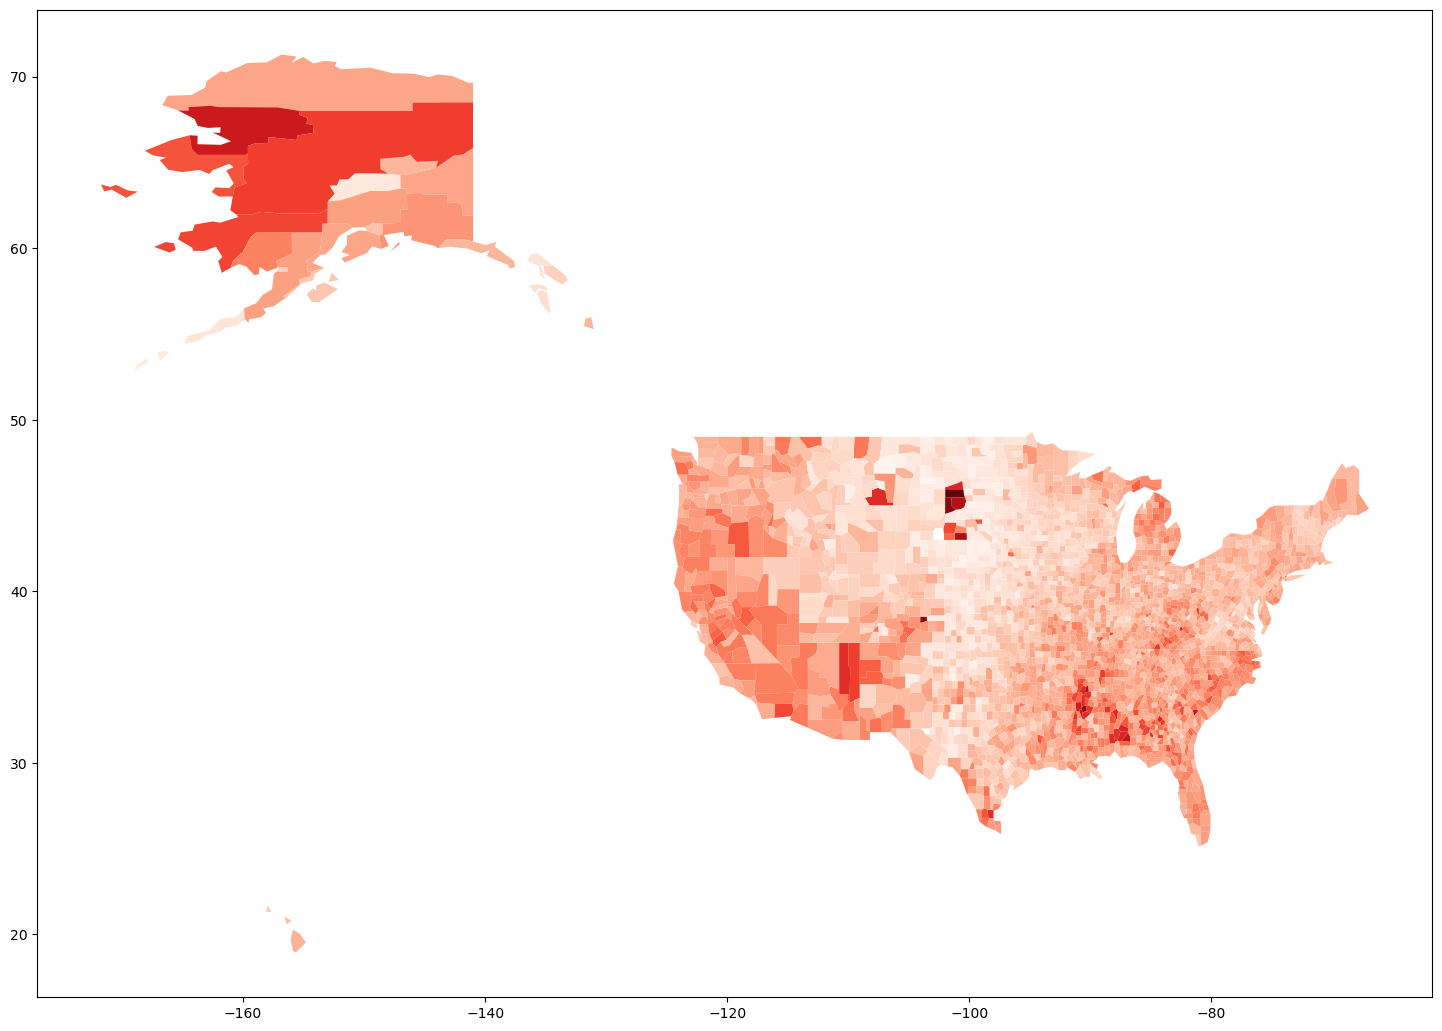

In [13]:
df.plot(column='Unemployment',
        cmap='Reds',
        figsize=(18,16))
plt.show()

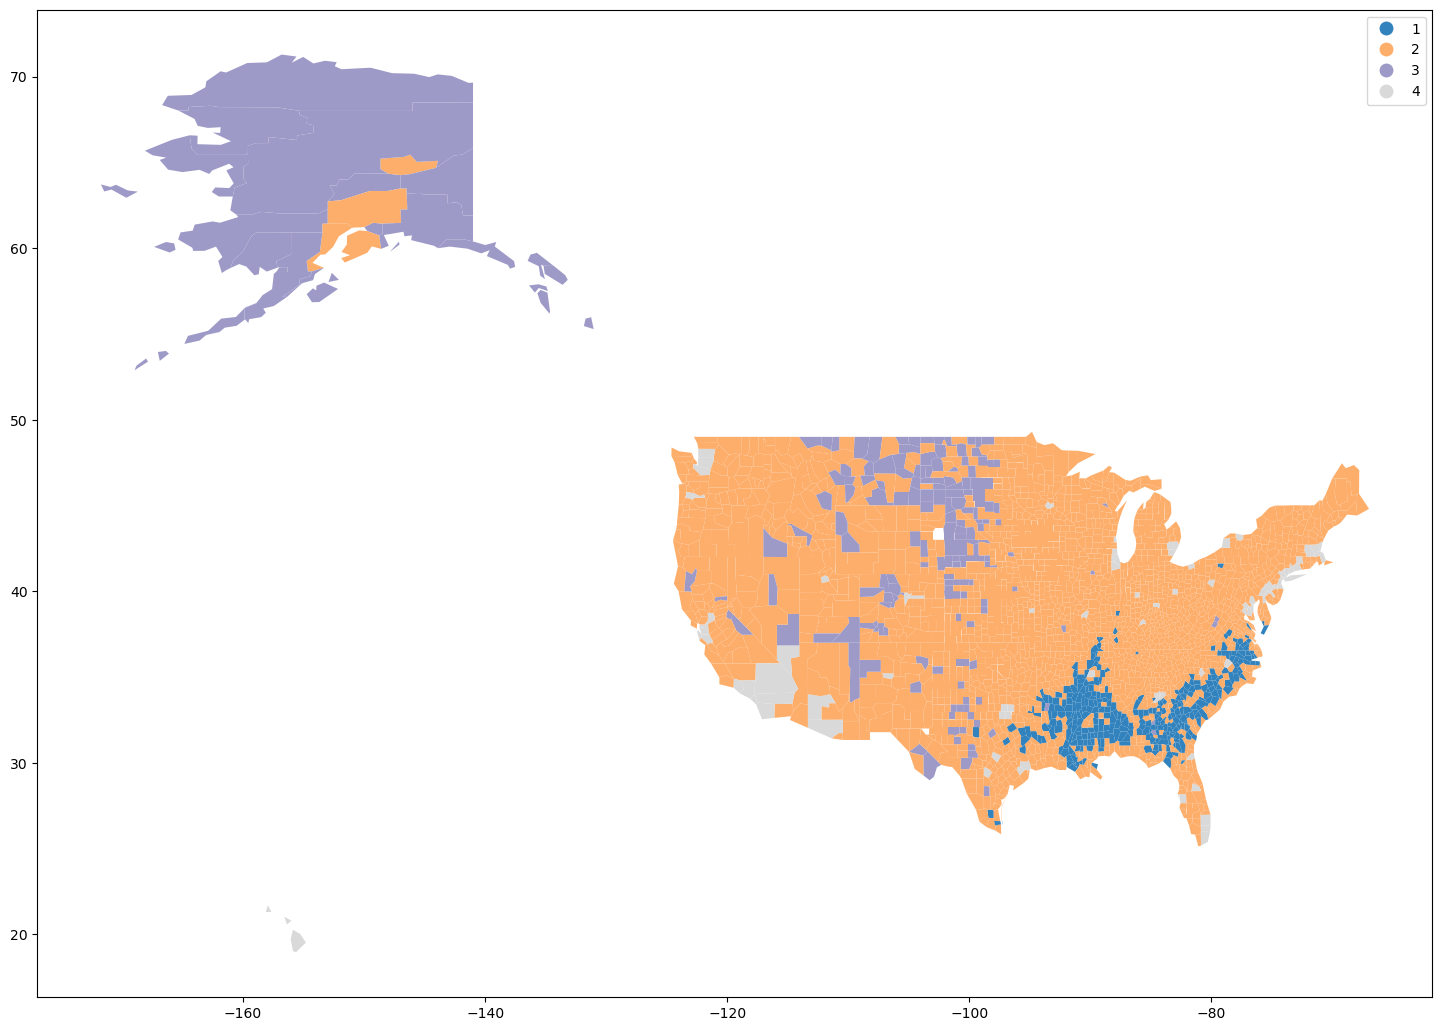

In [14]:
df.plot(column='cluster',
        cmap='tab20c',
        figsize=(18,16),
        categorical=True,
        legend=True)
plt.show()